In [1]:
import os, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
from py_util_dx.py_utils import setProjectPath
from evaluations import *

In [2]:
mpl.rcParams['font.family'] = 'helvetica'   # Global font family
mpl.rcParams['font.size'] = 12              # Global font size 
full_width = 8.5
half_width = full_width/2

In [3]:
projectPath, mainResultsPath = setProjectPath()
# datasets = ['MDTB', 'Demand', 'HCPur100', 'Language', 'Nishimoto', 'IBC']
datasets = ['MDTB']
surface_helpers_dir = os.path.join(projectPath, 'surface_helpers')
resultsPath = os.path.join(mainResultsPath, 'START_A7_spatialACF_map_LH')

## spatial ACF (across subjects in all the datasets)

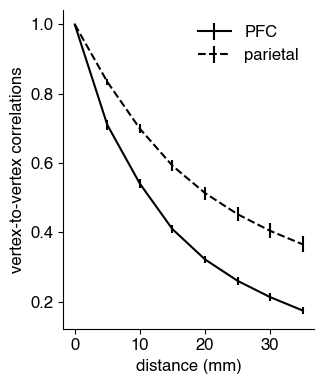

In [4]:
ROIs = ['PFC', 'parietal'] 
linestyles = ['-', '--']

fig, ax = plt.subplots(1, 1)
fig.set_figwidth(half_width*0.8) 
fig.set_figheight(4) 

for roiI in np.arange(len(ROIs)):
    corrs_this_roi = []
    for dataset_name in datasets:

        PKL_output = os.path.join(mainResultsPath, 'START_A7_spatialACF', dataset_name, f'output_{ROIs[roiI]}_cv.pkl')
        with open(PKL_output, 'rb') as pf:
            output = pickle.load(pf)

        corrs_this_roi.append(output['corrs'])
        distances = output['distances']

    corrs_this_roi = np.vstack(corrs_this_roi)
    corrs_mean = np.mean(corrs_this_roi, axis=0) 
    corrs_ste = np.std(corrs_this_roi, axis=0) / np.sqrt(corrs_this_roi.shape[0]) 

    ax.errorbar(distances, corrs_mean, corrs_ste, label=ROIs[roiI], linestyle=linestyles[roiI], color='k')  
    ax.set_xlabel('distance (mm)', fontsize=12) 
    ax.set_ylabel('vertex-to-vertex correlations', fontsize=12) 
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.legend(frameon=False, fontsize=12)  
plt.tight_layout() 

JPG_fig = os.path.join(resultsPath, f'spatial_ACF.jpg')
plt.savefig(JPG_fig, dpi=500, format='jpg') 

In [5]:
corrs_this_roi.shape 

(24, 8)

## ACF across all the datasets (avrg within each dataset first)

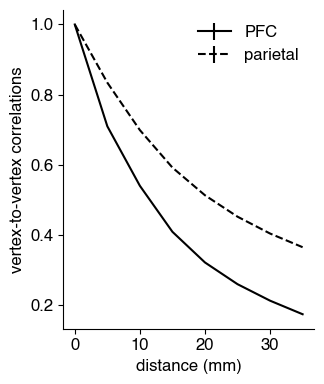

In [6]:
ROIs = ['PFC', 'parietal'] 
linestyles = ['-', '--']

fig, ax = plt.subplots(1, 1)
fig.set_figwidth(half_width*0.8) 
fig.set_figheight(4) 

for roiI in np.arange(len(ROIs)):
    corrs_this_roi = []
    for dataset_name in datasets:

        PKL_output = os.path.join(mainResultsPath, 'START_A7_spatialACF', dataset_name, f'output_{ROIs[roiI]}_cv.pkl')
        with open(PKL_output, 'rb') as pf:
            output = pickle.load(pf)

        corrs_this_roi.append(output['corrs'].mean(axis=0))
        distances = output['distances']

    corrs_this_roi = np.array(corrs_this_roi)
    corrs_mean = np.mean(corrs_this_roi, axis=0) 
    corrs_ste = np.std(corrs_this_roi, axis=0) / np.sqrt(corrs_this_roi.shape[0]) 

    ax.errorbar(distances, corrs_mean, corrs_ste, label=ROIs[roiI], linestyle=linestyles[roiI], color='k')  
    ax.set_xlabel('distance (mm)', fontsize=12) 
    ax.set_ylabel('vertex-to-vertex correlations', fontsize=12) 
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.legend(frameon=False, fontsize=12)  
plt.tight_layout() 

JPG_fig = os.path.join(resultsPath, f'spatial_ACF_mean_across_datasets.jpg')
plt.savefig(JPG_fig, dpi=500, format='jpg') 

In [7]:
corrs_this_roi.shape

(1, 8)